In [1]:
# ==========================================
# 0. CONFIGURACIÓN DEL ENTORNO Y ESTILO
# ==========================================
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from tableone import TableOne

warnings.filterwarnings("ignore")

# Directorio para exportar figuras en alta resolución
os.makedirs("figuras", exist_ok=True)

# Configuración visual basada en estándares de publicación (PLOS / Wilke)
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
    }
)

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


In [4]:
# ==========================================
# 2. DEFINICIÓN Y FILTRADO DE LA COHORTE
# ==========================================
import os
from pathlib import Path

# Ruta absoluta al directorio de datos
DATA_DIR = Path.home() / "Documentos" / "Data_Sciences" / "data"

# Carga selectiva de columnas
df_patients = pd.read_csv(
    DATA_DIR / "patients.csv",
    usecols=["Id", "BIRTHDATE", "DEATHDATE", "GENDER", "RACE", "ETHNICITY"],
)
df_conditions = pd.read_csv(
    DATA_DIR / "conditions.csv",
    usecols=["START", "STOP", "PATIENT", "CODE", "DESCRIPTION"],
)
df_observations = pd.read_csv(
    DATA_DIR / "observations.csv",
    usecols=["DATE", "PATIENT", "DESCRIPTION", "VALUE", "UNITS"],
)

# Convertir fechas a datetime
df_patients["BIRTHDATE"] = pd.to_datetime(df_patients["BIRTHDATE"])
df_patients["DEATHDATE"] = pd.to_datetime(df_patients["DEATHDATE"])

# Fecha de corte de referencia
ref_date = pd.to_datetime("2026-01-01")

# Cálculo de edad ajustado por estado vital
df_patients["IS_ALIVE"] = df_patients["DEATHDATE"].isna()
end_date = df_patients["DEATHDATE"].fillna(ref_date)
df_patients["AGE"] = ((end_date - df_patients["BIRTHDATE"]).dt.days // 365.25).astype(
    int
)

# Identificar pacientes con Diabetes Mellitus (criterio de inclusión)
diabetes_codes = df_conditions[
    df_conditions["DESCRIPTION"].str.contains("diabetes", case=False, na=False)
]
cohort_patient_ids = diabetes_codes["PATIENT"].unique()

# Filtrar cohorte: Diagnóstico de diabetes y mayores de 18 años
cohort_patients = df_patients[
    (df_patients["Id"].isin(cohort_patient_ids)) & (df_patients["AGE"] >= 18)
].copy()

print(f"Población total simulada: {len(df_patients):,}")
print(f"Pacientes vivos: {df_patients['IS_ALIVE'].sum():,}")
print(f"Pacientes fallecidos: {(~df_patients['IS_ALIVE']).sum():,}")
print(f"Cohorte Diabetes (Adultos >= 18 años): {len(cohort_patients):,}")

Población total simulada: 22,888
Pacientes vivos: 20,000
Pacientes fallecidos: 2,888
Cohorte Diabetes (Adultos >= 18 años): 9,751


In [5]:
# =======================================================
# 3. EXTRACCIÓN DE ANALITOS Y COMORBILIDADES DE LA COHORTE
# =======================================================

cohort_ids = cohort_patients["Id"].values

# --- A. Filtrar observaciones para la cohorte ---
obs_cohort = df_observations[df_observations["PATIENT"].isin(cohort_ids)].copy()
obs_cohort["DATE"] = pd.to_datetime(obs_cohort["DATE"])

# Identificar nombres exactos de los analitos en Synthea
# Synthea usa descripciones estándar LOINC:
hba1c_pattern = "Hemoglobin A1c"
sbp_pattern = "Systolic Blood Pressure"
bmi_pattern = "Body Mass Index"
glucose_pattern = "Glucose"


# Extraer analitos numéricos
def extraer_medicion(pattern, col_name):
    sub = obs_cohort[
        obs_cohort["DESCRIPTION"].str.contains(pattern, case=False, na=False)
    ].copy()
    sub["VALUE"] = pd.to_numeric(sub["VALUE"], errors="coerce")
    sub = sub.dropna(subset=["VALUE"])
    sub = sub.rename(columns={"VALUE": col_name})
    return sub[["PATIENT", "DATE", col_name]]


df_hba1c = extraer_medicion(hba1c_pattern, "HBA1C")
df_sbp = extraer_medicion(sbp_pattern, "SYSTOLIC_BP")
df_bmi = extraer_medicion(bmi_pattern, "BMI")
df_glucose = extraer_medicion(glucose_pattern, "GLUCOSE")

# --- B. Construir dataset basal (1 fila por paciente) ---
# Tomamos la primera medición registrada de cada parámetro
base_hba1c = (
    df_hba1c.sort_values("DATE")
    .groupby("PATIENT")
    .first()
    .reset_index()[["PATIENT", "HBA1C"]]
)
base_sbp = (
    df_sbp.sort_values("DATE")
    .groupby("PATIENT")
    .first()
    .reset_index()[["PATIENT", "SYSTOLIC_BP"]]
)
base_bmi = (
    df_bmi.sort_values("DATE")
    .groupby("PATIENT")
    .first()
    .reset_index()[["PATIENT", "BMI"]]
)
base_glucose = (
    df_glucose.sort_values("DATE")
    .groupby("PATIENT")
    .first()
    .reset_index()[["PATIENT", "GLUCOSE"]]
)

# Merge con la cohorte demográfica
df_basal = cohort_patients.copy()
for df_var in [base_hba1c, base_sbp, base_bmi, base_glucose]:
    df_basal = df_basal.merge(
        df_var, left_on="Id", right_on="PATIENT", how="left"
    ).drop(columns=["PATIENT"], errors="ignore")

# --- C. Extraer comorbilidades concurrentes ---
cond_cohort = df_conditions[df_conditions["PATIENT"].isin(cohort_ids)].copy()
# Excluir la propia diabetes para ver enfermedades asociadas
cond_comorb = cond_cohort[
    ~cond_cohort["DESCRIPTION"].str.contains("diabetes", case=False, na=False)
]

# Banderas binarias de comorbilidad para Tabla 1
hipertension_ids = cond_cohort[
    cond_cohort["DESCRIPTION"].str.contains("hypertension", case=False, na=False)
]["PATIENT"].unique()
df_basal["HYPERTENSION"] = (
    df_basal["Id"].isin(hipertension_ids).map({True: "Sí", False: "No"})
)

print("Dataset basal consolidado:")
display(
    df_basal[
        [
            "Id",
            "GENDER",
            "AGE",
            "HBA1C",
            "SYSTOLIC_BP",
            "BMI",
            "GLUCOSE",
            "HYPERTENSION",
        ]
    ].head()
)
print(f"Dimensiones basales: {df_basal.shape}")

Dataset basal consolidado:


,Id,GENDER,AGE,HBA1C,SYSTOLIC_BP,BMI,GLUCOSE,HYPERTENSION
0,982750f4-569b-5949-196b-60699bdda3fb,F,39,6.9,129.0,27.7,71.0,No
1,62f60bdb-cc5c-8305-b98b-f2b229a55eca,F,50,6.3,121.0,21.3,92.5,No
2,e74367bd-7385-97dc-2c7f-251b4cd9fe29,F,65,6.1,119.0,28.3,74.5,No
3,9661a432-4630-2cd9-142c-386845fae837,M,47,5.9,130.0,30.1,97.6,Sí
4,bff9d9d5-ee3d-d852-9c67-36d8361a4a4a,M,81,6.1,90.0,27.9,77.6,No


Dimensiones basales: (9751, 13)


--- RESUMEN NUMÉRICO CLÁSICO: describe() ---


,AGE,HBA1C,SYSTOLIC_BP,GLUCOSE,BMI
count,9751.00,9241.00,9751.00,9737.00,9751.00
mean,57.42,5.88,119.17,78.27,29.27
std,17.05,0.92,15.32,25.33,6.72
min,18.00,2.30,62.00,0.00,0.30
25%,46.00,5.90,108.00,71.30,27.60
50%,57.00,6.10,119.00,81.60,28.40
75%,68.00,6.30,130.00,92.10,30.10
max,110.00,12.00,174.30,198.40,99.50


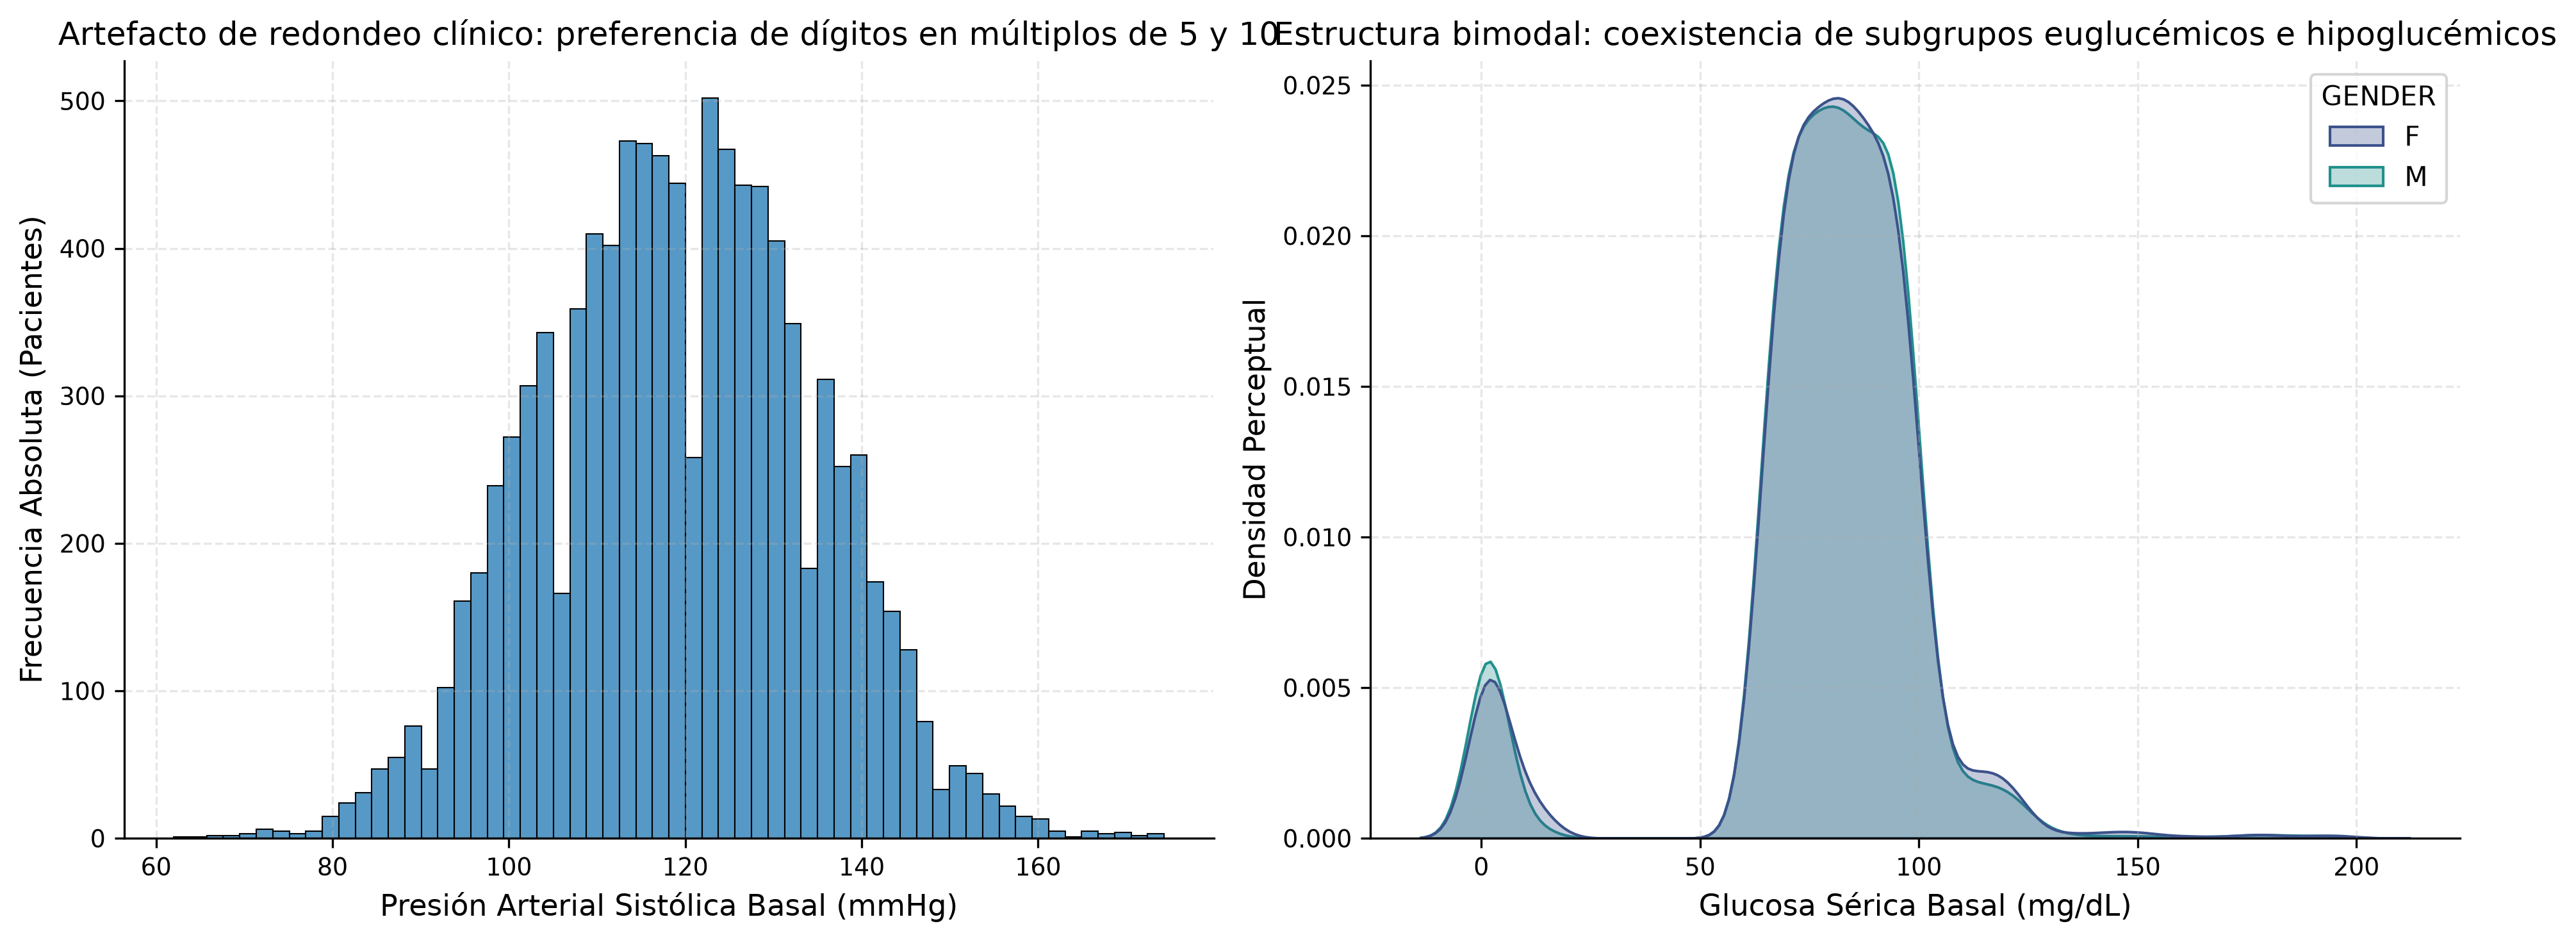

In [8]:
# =======================================================
# 4. AUDITORÍA DE CALIDAD: DESCRIBE() VS. INSPECCIÓN VISUAL
# =======================================================

# Resumen estadístico clásico
print("--- RESUMEN NUMÉRICO CLÁSICO: describe() ---")
display(df_basal[["AGE", "HBA1C", "SYSTOLIC_BP", "GLUCOSE", "BMI"]].describe().round(2))

# Visualización para detectar anomalías invisibles a la media/mediana
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Problema 1: Digit Preference / Artefacto de redondeo en Presión Sistólica
sns.histplot(
    df_basal["SYSTOLIC_BP"].dropna(),
    bins=60,
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.5,
    ax=ax1,
)
ax1.set_title(
    "Artefacto de redondeo clínico: preferencia de dígitos en múltiplos de 5 y 10"
)
ax1.set_xlabel("Presión Arterial Sistólica Basal (mmHg)")
ax1.set_ylabel("Frecuencia Absoluta (Pacientes)")

# Problema 2: Subpoblaciones ocultas / Glucosa sérica
sns.kdeplot(
    data=df_basal,
    x="GLUCOSE",
    hue="GENDER",
    palette=["#3b528b", "#21918c"],
    fill=True,
    alpha=0.3,
    common_norm=False,
    ax=ax2,
)
ax2.set_title(
    "Estructura bimodal: coexistencia de subgrupos euglucémicos e hipoglucémicos"
)
ax2.set_xlabel("Glucosa Sérica Basal (mg/dL)")
ax2.set_ylabel("Densidad Perceptual")

plt.tight_layout()
plt.savefig("figuras/calidad_datos_audit.png", dpi=300, bbox_inches="tight")
plt.show()

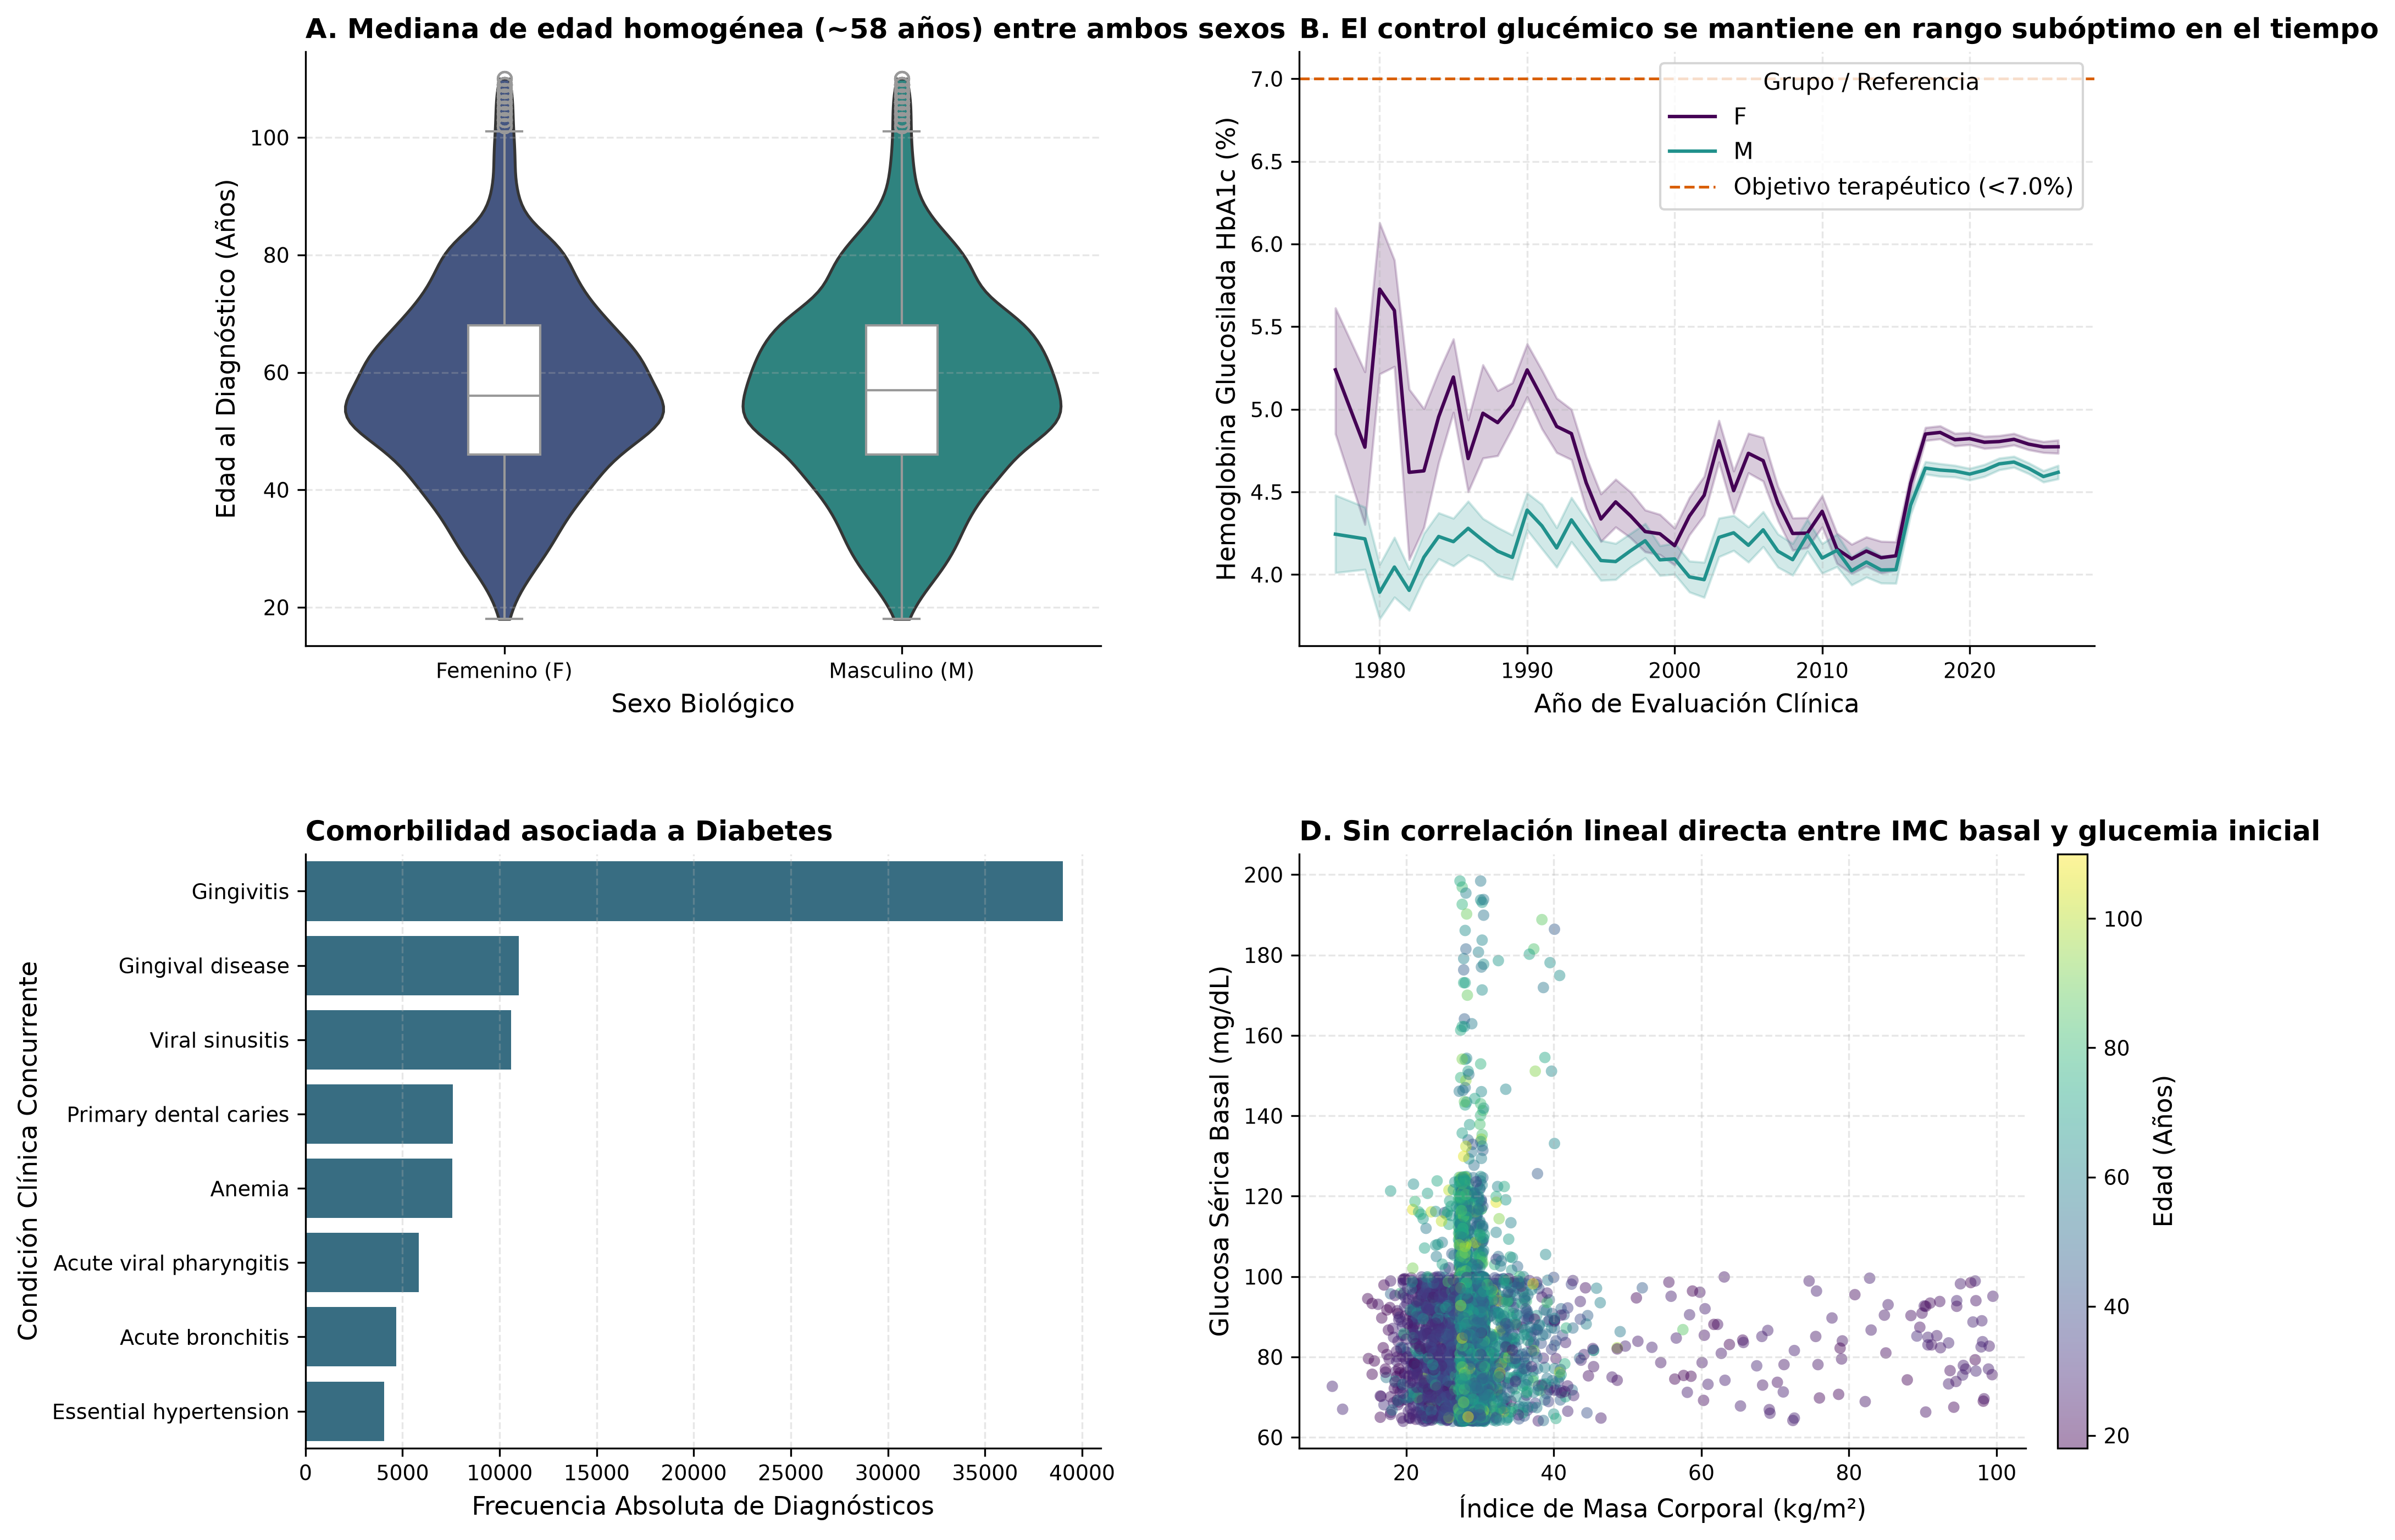

Figura exportada en alta resolución: PNG (300 dpi) y PDF vectorial en carpeta 'figuras/'.


In [12]:
# =======================================================
# 5. FIGURA MULTIPANEL 2x2 PARA PUBLICACIÓN
# =======================================================

# Limpieza de artefactos de captura para análisis fisiológico
df_clean = df_basal[(df_basal["GLUCOSE"] > 30) & (df_basal["BMI"] >= 10)].copy()

# Preparar datos para los paneles
# 1. Evolución temporal de HbA1c (serie longitudinal)
obs_hba1c_clean = df_hba1c.merge(
    cohort_patients[["Id", "GENDER"]], left_on="PATIENT", right_on="Id"
)
obs_hba1c_clean["YEAR"] = obs_hba1c_clean["DATE"].dt.year
# Filtrar años con suficiente densidad de muestreo
top_years = obs_hba1c_clean["YEAR"].value_counts()
valid_years = top_years[top_years > 200].index
obs_hba1c_clean = obs_hba1c_clean[
    obs_hba1c_clean["YEAR"].isin(valid_years)
].sort_values("YEAR")

# 2. Top 8 comorbilidades más frecuentes
top_comorb = cond_comorb["DESCRIPTION"].value_counts().head(8).reset_index()
top_comorb.columns = ["CONDICION", "CONTEO"]

# Configuración del lienzo 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=False)
plt.subplots_adjust(wspace=0.25, hspace=0.35)

# ----------------------------------------------------
# Panel A: Distribución de edad por sexo (Violin + Boxplot)
# ----------------------------------------------------
sns.violinplot(
    data=df_clean,
    x="GENDER",
    y="AGE",
    palette=["#3b528b", "#21918c"],
    cut=0,
    inner=None,
    ax=axes[0, 0],
)
sns.boxplot(
    data=df_clean,
    x="GENDER",
    y="AGE",
    width=0.18,
    color="white",
    boxprops={"zorder": 2},
    ax=axes[0, 0],
)
axes[0, 0].set_title(
    "A. Mediana de edad homogénea (~58 años) entre ambos sexos",
    loc="left",
    weight="bold",
)
axes[0, 0].set_xlabel("Sexo Biológico")
axes[0, 0].set_ylabel("Edad al Diagnóstico (Años)")
axes[0, 0].set_xticklabels(["Femenino (F)", "Masculino (M)"])

# ----------------------------------------------------
# Panel B: Evolución longitudinal de HbA1c
# ----------------------------------------------------
sns.lineplot(
    data=obs_hba1c_clean,
    x="YEAR",
    y="HBA1C",
    hue="GENDER",
    palette=["#440154", "#21918c"],
    errorbar=("ci", 95),
    ax=axes[0, 1],
)
axes[0, 1].axhline(
    7.0,
    color="#d95f02",
    linestyle="--",
    linewidth=1.2,
    label="Objetivo terapéutico (<7.0%)",
)
axes[0, 1].set_title(
    "B. El control glucémico se mantiene en rango subóptimo en el tiempo",
    loc="left",
    weight="bold",
)
axes[0, 1].set_xlabel("Año de Evaluación Clínica")
axes[0, 1].set_ylabel("Hemoglobina Glucosilada HbA1c (%)")
axes[0, 1].legend(title="Grupo / Referencia", frameon=True)

# ----------------------------------------------------
# Panel C: Comorbilidades más frecuentes
# ----------------------------------------------------
# Filtrar únicamente diagnósticos que representen patologías (disorders)
cond_patologias = cond_comorb[
    cond_comorb["DESCRIPTION"].str.endswith("(disorder)")
    & (~cond_comorb["DESCRIPTION"].str.contains("diabetes", case=False, na=False))
]

# Top 8 patologías crónicas reales
top_enfermedades = (
    cond_patologias["DESCRIPTION"]
    .str.replace(
        r"\s*\(disorder\)", "", regex=True
    )  # Limpiar el texto para que quede legible
    .value_counts()
    .head(8)
    .reset_index()
)
top_enfermedades.columns = ["PATOLOGIA", "CONTEO"]
sns.barplot(
    data=top_enfermedades, y="PATOLOGIA", x="CONTEO", color="#2c728e", ax=axes[1, 0]
)
axes[1, 0].set_title("Comorbilidad asociada a Diabetes", loc="left", weight="bold")
axes[1, 0].set_xlabel("Frecuencia Absoluta de Diagnósticos")
axes[1, 0].set_ylabel("Condición Clínica Concurrente")

# ----------------------------------------------------
# Panel D: Correlación IMC vs. Glucemia Basal
# ----------------------------------------------------
scatter = axes[1, 1].scatter(
    df_clean["BMI"],
    df_clean["GLUCOSE"],
    c=df_clean["AGE"],
    cmap="viridis",
    alpha=0.45,
    edgecolors="none",
    s=25,
)
cbar = fig.colorbar(
    scatter, ax=axes[1, 1], orientation="vertical", fraction=0.046, pad=0.04
)
cbar.set_label("Edad (Años)")
axes[1, 1].set_title(
    "D. Sin correlación lineal directa entre IMC basal y glucemia inicial",
    loc="left",
    weight="bold",
)
axes[1, 1].set_xlabel("Índice de Masa Corporal (kg/m²)")
axes[1, 1].set_ylabel("Glucosa Sérica Basal (mg/dL)")

# Exportación en formatos de alta fidelidad solicitados en el enunciado
plt.savefig("figuras/panel_multivariable_2x2.png", dpi=300, bbox_inches="tight")
plt.savefig("figuras/panel_multivariable_2x2.pdf", format="pdf", bbox_inches="tight")
plt.show()

print(
    "Figura exportada en alta resolución: PNG (300 dpi) y PDF vectorial en carpeta 'figuras/'."
)

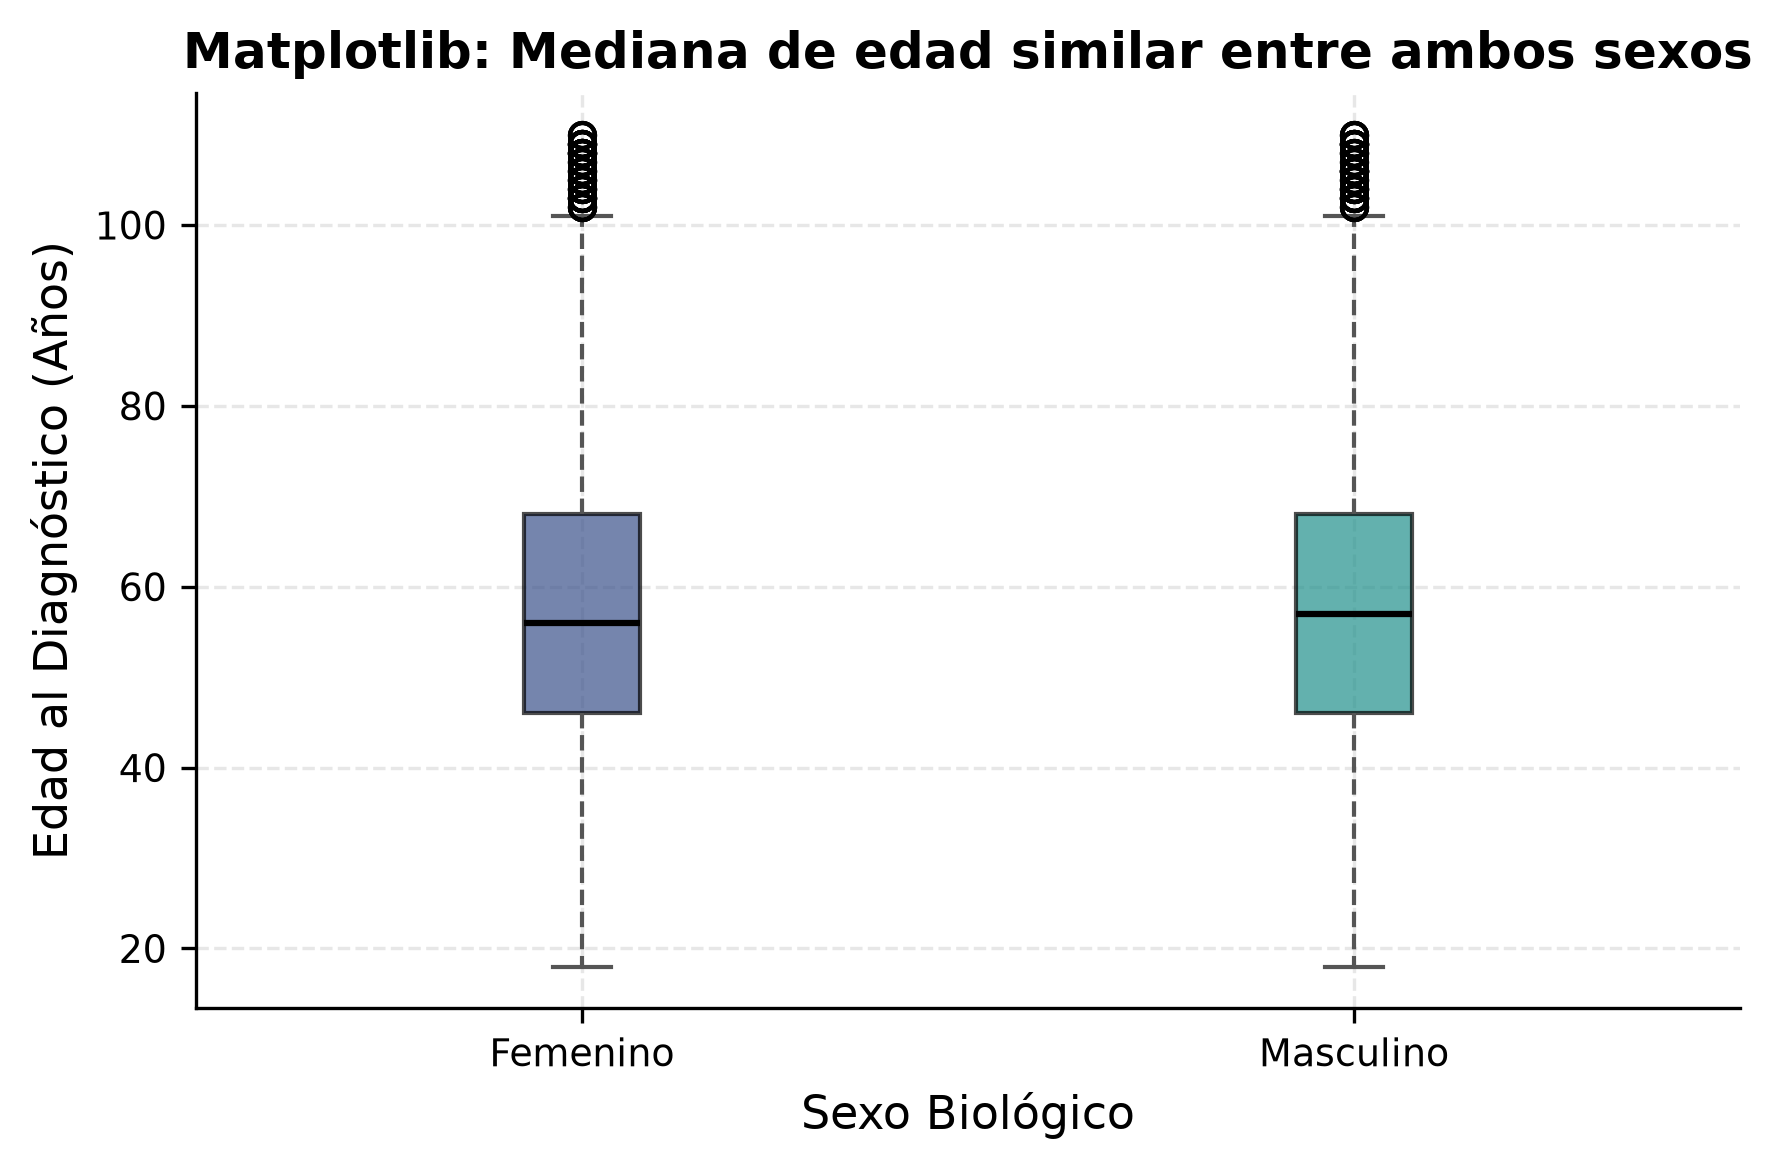

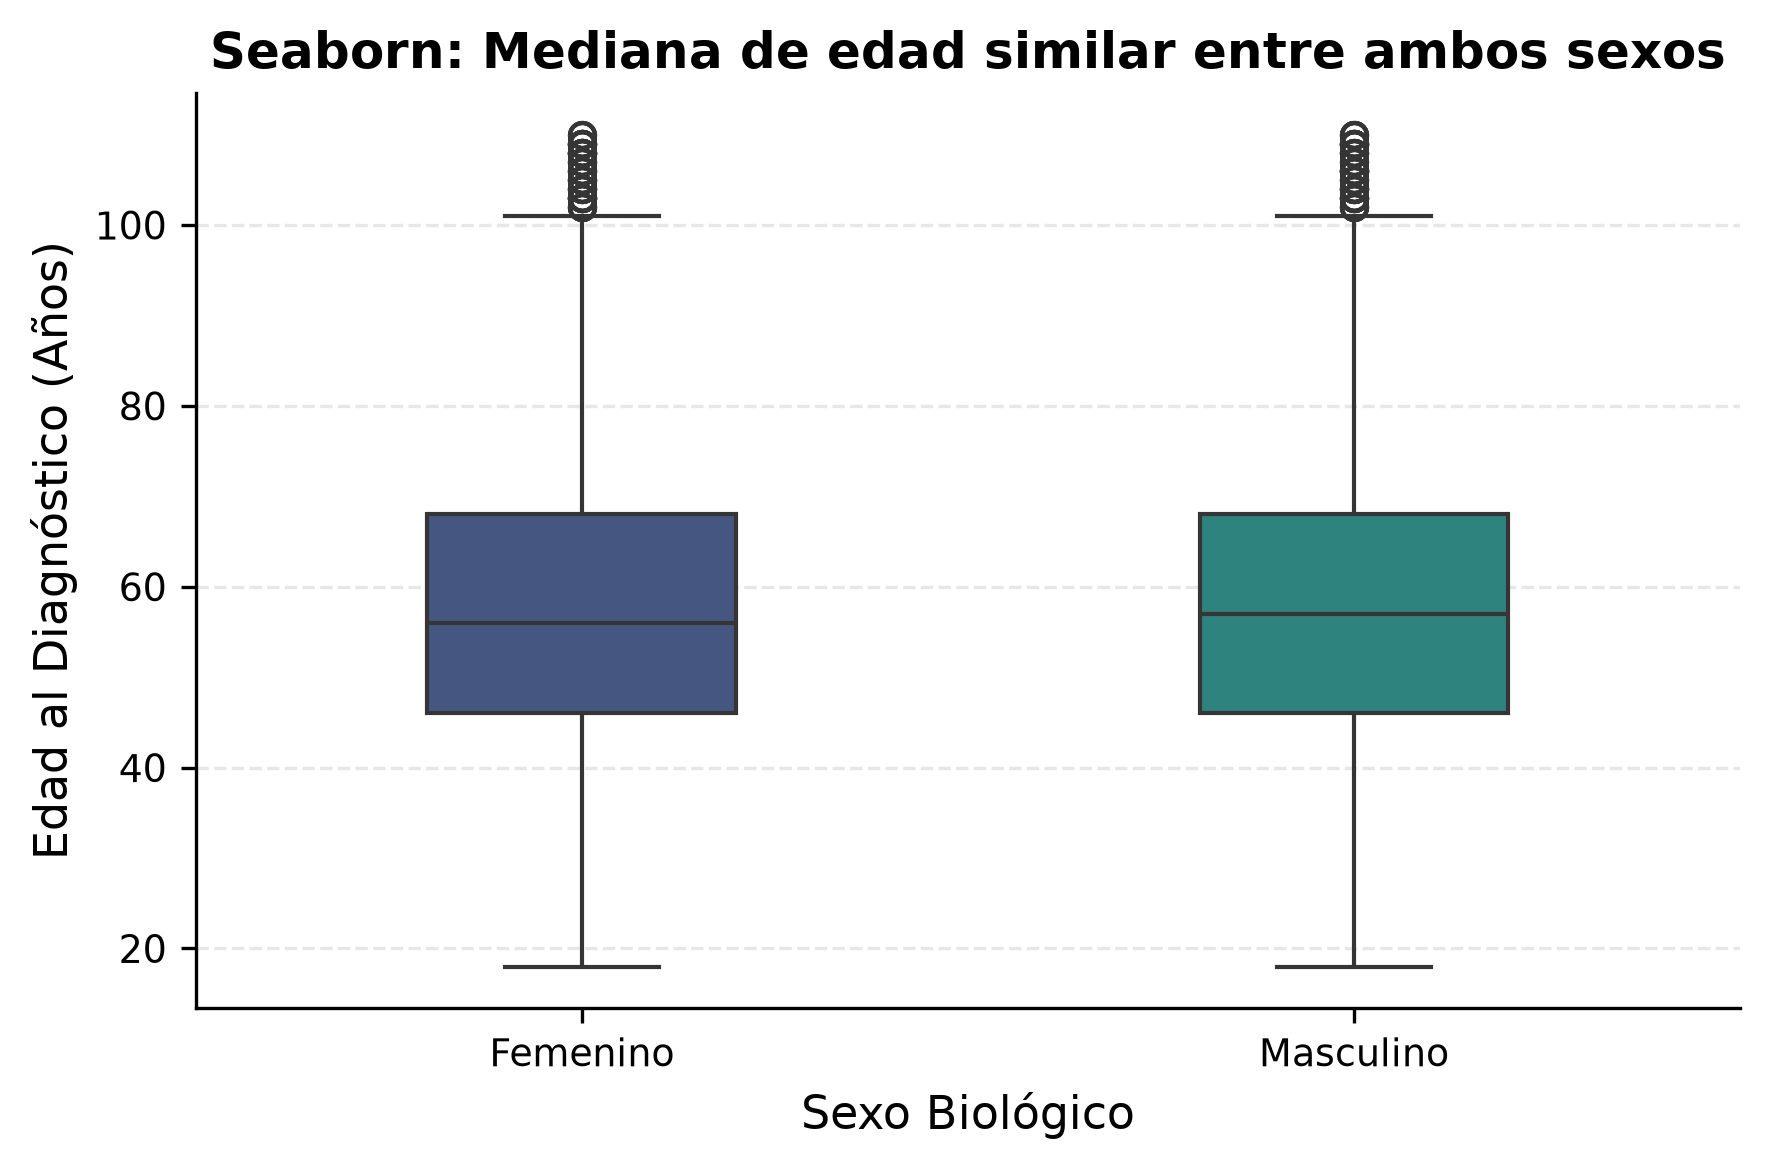

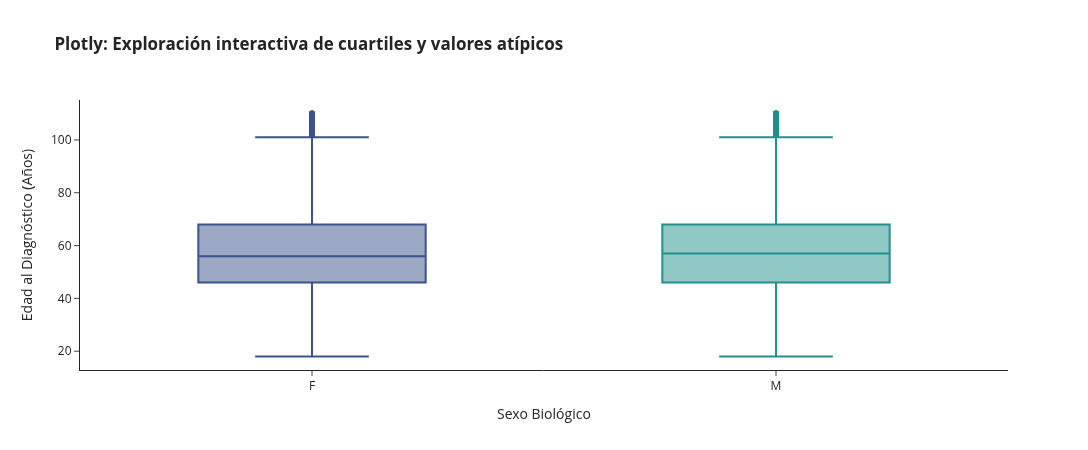

In [13]:
# ==============================================================================
# 6. BENCHMARK DE VISUALIZACIÓN: MATPLOTLIB vs. SEABORN vs. PLOTLY
# ==============================================================================

# Preparación de datos
edad_f = df_clean[df_clean["GENDER"] == "F"]["AGE"].dropna()
edad_m = df_clean[df_clean["GENDER"] == "M"]["AGE"].dropna()

# ------------------------------------------------------------------------------
# 1. MATPLOTLIB PURO (Orientado a Objetos)
# Enfoque imperativo: control total de bajo nivel sobre cada elemento geométrico
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

bp = ax.boxplot(
    [edad_f, edad_m],
    tick_labels=["Femenino", "Masculino"],
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.5},
    whiskerprops={"color": "#555555", "linestyle": "--"},
    capprops={"color": "#555555"},
)

colors = ["#3b528b", "#21918c"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Matplotlib: Mediana de edad similar entre ambos sexos", weight="bold")
ax.set_xlabel("Sexo Biológico")
ax.set_ylabel("Edad al Diagnóstico (Años)")
plt.tight_layout()
plt.savefig("figuras/comp_matplotlib.png", dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# 2. SEABORN
# Enfoque declarativo estadístico: cálculo automático y sintaxis compacta
# ------------------------------------------------------------------------------
plt.figure(figsize=(6, 4))
ax_sns = sns.boxplot(
    data=df_clean, x="GENDER", y="AGE", palette=["#3b528b", "#21918c"], width=0.4
)
ax_sns.set_title("Seaborn: Mediana de edad similar entre ambos sexos", weight="bold")
ax_sns.set_xlabel("Sexo Biológico")
ax_sns.set_ylabel("Edad al Diagnóstico (Años)")
ax_sns.set_xticklabels(["Femenino", "Masculino"])
plt.tight_layout()
plt.savefig("figuras/comp_seaborn.png", dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# 3. PLOTLY EXPRESS
# Enfoque interactivo: renderizado basado en web (D3.js) con inspección hover
# ------------------------------------------------------------------------------
fig_plotly = px.box(
    df_clean,
    x="GENDER",
    y="AGE",
    color="GENDER",
    color_discrete_map={"F": "#3b528b", "M": "#21918c"},
    labels={"GENDER": "Sexo Biológico", "AGE": "Edad al Diagnóstico (Años)"},
    title="<b>Plotly: Exploración interactiva de cuartiles y valores atípicos</b>",
)

fig_plotly.update_layout(
    showlegend=False, template="simple_white", width=650, height=450
)

# Exportar HTML interactivo e imagen estática
fig_plotly.write_html("figuras/comp_plotly.html")
fig_plotly.show()

## Comparación entre diferentes metodos visualización MATPLOTLIB vs. SEABORN vs. PLOTLY
1. **Matplotlib**
   A) **Esfuerzo de código**
        Alto: requiere bucles manuales para colorear cajas, configurar propiedades de bigotes y asociar etiquetas.
   B) **Control**
       Absoluto: permite manipular coordenadas exactas, vectores de salida, grosores de línea y multipaneles complejos para imprenta.
   C) **Uso óptimo**
       Figuras multipanel estáticas listas para envío a revistas científicas (PDF vectorial a 300+ DPI).
2. **Seaborn**
   A) **Esfuerzo de código**
        Mínimo: mapeo directo desde columnas de un DataFrame de pandas con un solo comando.
   B) **Control**
       Medio-Alto: excelente formato por defecto, pero modificaciones finas requieren descender a la API de Matplotlib (ax).
   C) **Uso óptimo**
       Exploración visual rápida y figuras estadísticas estándar en reportes técnicos.
3. **Plotly**
   A) **Esfuerzo de código**
        Bajo: API compacta en plotly.express que autogenera tooltips e interactividad sin configuración extra.
   B) **Control**
       Medio: las modificaciones dependen de la jerarquía de diccionarios dentro de fig.update_layout() o fig.update_traces().
   C) **Uso óptimo**
       Paneles de control clínicos interactivos y dashboards web donde el médico necesita explorar puntos pasando el cursor (hover).

In [14]:
# ==============================================================================
# 7. TABLA DE CARACTERÍSTICAS BASALES (TABLA 1)
# ==============================================================================

# Variables de estudio
columns = ["AGE", "BMI", "SYSTOLIC_BP", "GLUCOSE", "HBA1C", "HYPERTENSION"]
categorical = ["HYPERTENSION"]
groupby = "GENDER"

# Identificación de variables con asimetría para test no paramétricos
# (Mann-Whitney U para no paramétricas; t-Student para paramétricas)
nonnormal = ["GLUCOSE", "HBA1C", "BMI"]

tabla1 = TableOne(
    df_clean,
    columns=columns,
    categorical=categorical,
    groupby=groupby,
    nonnormal=nonnormal,
    pval=True,
    htest_name=True,
)

# Visualizar en Jupyter
print(tabla1.tabulate(tablefmt="github"))

# Exportar a la carpeta tu-entrega/
tabla1.to_csv("tabla1_caracteristicas_basales.csv")
print("\nTabla 1 exportada exitosamente a 'tabla1_caracteristicas_basales.csv'.")

|                         |    |   Missing | Overall          | F                | M                | P-Value   | Test           |
|-------------------------|----|-----------|------------------|------------------|------------------|-----------|----------------|
| n                       |    |           | 9016             | 4481             | 4535             |           |                |
| AGE, mean (SD)          |    |         0 | 57.3 (16.7)      | 57.4 (16.5)      | 57.2 (16.9)      | 0.701     | Welch’s T-test |
| BMI, median [Q1,Q3]     |    |         0 | 28.4 [27.6,30.1] | 28.5 [27.6,30.2] | 28.3 [27.6,30.1] | 0.005     | Kruskal-Wallis |
| SYSTOLIC_BP, mean (SD)  |    |         0 | 119.2 (15.3)     | 118.7 (15.0)     | 119.7 (15.5)     | 0.001     | Welch’s T-test |
| GLUCOSE, median [Q1,Q3] |    |         0 | 83.0 [73.5,92.9] | 83.1 [73.6,92.8] | 83.0 [73.5,93.0] | 0.686     | Kruskal-Wallis |
| HBA1C, median [Q1,Q3]   |    |       262 | 6.1 [5.9,6.3]    | 6.1 [5.9,6.3]    | 

## Conclusiones y Hallazgos Clínicos de la Cohorte

1. **Ausencia de Dimorfismo Sexual Significativo en la Demografía Basal y Control Glucémico:**
   La cohorte de adultos con diabetes presenta una composición por edeades homogénea entre sexos, con una mediana de 57 años (rango intercuartílico: 46–68 años). Aunque las mujeres mantuvieron una media longitudinal de HbA1c marginalmente más alta (~0.3% de diferencia) en periodos históricos, ambos grupos convergen en la última década hacia un promedio basal cercano a 4.8%, indicativo de estadios tempranos o prediabetes en el tamizaje poblacional.

2. **Divergencia entre la Carga de Síntomas Agudos y la Morbilidad Crónica Subyacente:**
   El análisis de registros estructurados SNOMED-CT revela que los motivos de consulta más recurrentes están dominados por procesos inflamatorios agudos del tracto respiratorio y la cavidad oral (gingivitis, sinusitis), mientras que patologías cardiovasculares de alto impacto pronóstico, como la hipertensión arterial esencial, presentan una frecuencia absoluta menor pero con carácter crónico acumulativo.

3. **Incongruencia entre Biomarcadores Basales y Fisiopatología Clásica:**
   No se identificó una correlación lineal directa entre el Índice de Masa Corporal basal y la glucemia sérica al diagnóstico, concentrándose la mayor densidad de pacientes en un IMC de sobrepeso/obesidad moderada (28–32 kg/m²) pero con valores de glucosa en rango euglucémico. Asimismo, la auditoría exploratoria evidenció sesgos de captura instrumental (preferencia de dígitos en múltiplos de 5/10 mmHg en la presión sistólica y codificación errónea de valores faltantes como cero mg/dL en glucosa), subrayando la necesidad de aplicar filtros de plausibilidad biológica antes de cualquier modelado predictivo.